# 1. Mô tả

- File này để trả lời 2 câu hỏi có thể trả lời được dựa vào dữ liệu sẵn có. Ngoài ra, để tăng thách thức (aka công việc), các câu hỏi này để trả lời thiếu phục, ý nghĩa và phù hợp với thực tế còn cần nhóm phải tra cứu, tìm tòi, tích hợp thêm một số thông tin bên ngoài. 

- Các câu hỏi chỉ dựa vào mỗi dữ liệu `original_data` để trả lời, rút ra insight và giả thuyết đã được nhóm trình bày ở **02_general_eda.ipynb**. 

- Nghĩa là nhóm đã có và trình bày nhiều hơn 4 câu hỏi / giả thuyết, và 4 câu hỏi được trình bày ở 2 file 03.ipynb là những câu hỏi khó, thử thách nhất.

# 2. Câu hỏi

## Câu hỏi 1: Lương ngành Data tăng là do giá trị thật hay do lạm phát?

**Cụ thể:**   
Phân tích mức tăng trưởng lương trung vị (median salary) hàng năm của các **Senior** trong ngành Data tại **thị trường Mỹ** (nơi chiếm đa số dữ liệu và sử dụng USD) và so sánh tốc độ tăng trưởng này với tỷ lệ lạm phát (CPI) của Mỹ trong cùng kỳ **2022-2025**.

### Động lực & Lợi ích

**Động lực:**  
Trong vài năm qua, con số lương ngành IT và Data được báo cáo là tăng phi mã. Tuy nhiên, nếu mức tăng này chỉ ngang bằng với lạm phát, thì sức mua thực tế của nhân sự không đổi. Việc xác định xem đây là tăng trưởng "thực" hay chỉ là "trượt giá" là rất quan trọng để đánh giá sức hấp dẫn thực sự của ngành.

**Lợi ích:**
- Giúp phân biệt giữa "bong bóng" lương và sự gia tăng giá trị nội tại của nghề.
- Xác định xem thị trường đang trong giai đoạn "bùng nổ" (Boom), "bão hòa" (Stagnation) hay "suy thoái" (Recession).

**Đối tượng quan tâm?**
- Người tìm việc: Để đặt kỳ vọng lương hợp lý và deal lương theo giá trị thực chứ không chỉ theo con số danh nghĩa.
- Nhà tuyển dụng: Để hoạch định ngân sách nhân sự, biết khi nào cần tăng lương để giữ chân nhân tài trước áp lực lạm phát.
- Người định hướng nghề nghiệp: Đánh giá tiềm năng dài hạn của ngành.

**Vấn đề thực tế:**  
Quyết định có nên chuyển việc để tăng lương hay không, và định vị mức lương đề xuất sao cho không bị lỗ thực tế.

## Câu hỏi 2: Cơn sốt AI (ChatGPT bùng nổ cuối 2022) tác động thế nào đến cấu trúc lương ngành Data?

**Cụ thể:**  
Phân loại cột `job_title` thành hai nhóm định danh **AI/ML** vs. **Traditional Data Roles**, sau đó tính toán mức lương trung bình (salary_in_usd) theo từng năm (work_year) và so sánh hệ số góc (độ dốc) của đường xu hướng để xem xu hướng lương giữa 2 nhóm như thể nào **sau năm 2022**.

### Động lực & Lợi ích

**Động lực:**  
Năm 2022, ChatGPT bùng nổ, thị trường công nghệ đang trải qua "cơn sốt" AI. Nhiều giả định cho rằng "kỹ sư AI/ML được tăng lương đột biến, còn Data Analyst truyền thống thì chững lại", nhưng thường chỉ dựa trên các nhận định cảm tính hoặc tin tức truyền thông. Việc phân tich dữ liệu thực tế sẽ giúp kiểm chứng nhận định trên.

**Lợi ích:**  
- Định lượng giá trị kỹ năng: Cho thấy mức trả thêm mà thị trường sẵn sàng trả cho các kỹ năng GenAI/ML so với kỹ năng phân tích dữ liệu thông thường.
- Dự báo xu hướng: Độ dốc của biểu đồ sẽ cho biết tốc độ tăng trưởng, giúp dự đoán liệu khoảng cách thu nhập giữa hai nhóm này sẽ nới rộng hay thu hẹp trong tương lai gần.

**Đối tượng quan tâm:**   
- Người lao động (Data Professionals): Các Data Analyst/Scientist đang cân nhắc xem có nên đầu tư thời gian học thêm về Deep Learning/LLMs để chuyển hướng sự nghiệp (pivot) hay không.
- Nhà tuyển dụng & HR: Cần dữ liệu chuẩn (benchmark) để xây dựng khung lương cạnh tranh cho các vị trí AI, tránh việc trả quá cao (overpaying) do hype hoặc quá thấp khiến mất nhân tài.
- Sinh viên & Cơ sở đào tạo: Định hướng chuyên ngành học phù hợp với nhu cầu và đãi ngộ của thị trường.

**Vấn đề thực tế:**  
- Quyết định lộ trình thăng tiến cá nhân: "Tôi nên đào sâu vào SQL/Tableau hay bắt đầu học PyTorch/TensorFlow để tối ưu thu nhập?"

# 3. Code tìm câu trả lời

### Import thư viện

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

In [15]:
# Load the dataset
df = pd.read_csv('../data/original_data.csv')

## Câu hỏi 1

### A. Tiền xử lí

**1. Lọc chỉ lấy thị trường Mỹ:**  
Để trả lời câu hỏi này một cách chính xác, chúng ta cần loại bỏ yếu tố sai lệch do sự thay đổi về địa lý. Ví dụ: 
- Dữ liệu các năm sau có thêm nhiều công ty Mỹ hơn nên lương trung bình năm đó cao hơn.
- Lạm phát ở Mỹ khác với lạm phát ở Việt Nam hay Ấn Độ.  
Do đó, để đảm bảo tính nhất quán, phân tích dưới đây chỉ xét riêng 1 thị trường. Ở đây chúng em chọn Mỹ (US) vì dữ liệu lương `salary_in_usd` thường lấy Mỹ làm chuẩn, điều này cũng giúp loại bỏ sai số do quy đổi tỷ giá tiền tệ giữa các nước, và dữ liệu lạm phát (CPI) của Mỹ rất minh bạch .

**2. Lọc chỉ lấy nhân viên Full-time:**  
Dataset này cung cấp Lương Tổng Cả Năm (Annual Salary), chứ không cung cấp Lương theo giờ (Hourly Rate) hay số giờ làm việc. Nếu gộp chung Full-time và Part-time thì sẽ nhầm lẫn lương ngành này giảm, nhưng thực tế đơn giá lao động không đổi. Để so sánh công bằng và tránh nhiễu, chúng ta chỉ giữ lại những nhân viên Full-time để tránh lương các loại làm việc khác làm lệch số liệu

**Bước làm:**  
- Tạo dataframe mới `df_clean` với các hàng có điều kiện `employment_type` = FT và `company_location` = US bằng`.copy()` để tạo ra một bản sao độc lập (deep copy) cho biến df_clean, để tránh khi sửa dữ liệu trên df_clean, nó có thể làm thay đổi cả bảng gốc

In [16]:
# Lọc dũ liệu chỉ lấy nhân viên full-time, ở Mỹ
df_clean = df[
    (df['employment_type'] == 'FT') &
    (df['company_location'] == 'US')           
].copy()

**3. Vấn đề:**  
Theo như **mục 2.2.1 trong notebook 02_general_eda**, số lượng sample  theo từng năm có sự chênh lệch đặc biệt giữa năm 2020 (mẫu nhỏ - High Variance) chỉ có 75 bản ghi và năm 2024 (mẫu lớn - Low Variance). Vậy nên việc so sánh giữa 2020 và 2024 là không ổn nếu muốn có độ chính xác cao.

**Giải pháp:**  
**Lọc chỉ lấy dữ liệu từ năm 2022 trở đi** vì số lượng sample từng năm từ 2022 trở đi đã >= 1000. Tuy ở năm 2022 (1,334 mẫu) vẫn còn chênh lệch so với năm 2024 (56,000 mẫu) nhưng trong thống kê có **Luật số lớn (Law of Large Numbers)**, khi mẫu đạt đến một ngưỡng nhất định (thường > 1000 cho các khảo sát xã hội học/kinh tế), thì giá trị trung bình/trung vị đã bão hòa và phản ánh đúng tổng thể (population).

**Bước làm:**  
- Tiếp tục lọc `df_clean` với các hàng có điều kiện `work_year` >= 2022 

In [17]:
# Lọc dữ liệu tính từ năm 2022 trở đi
df_clean = df_clean[(df_clean['work_year'] >= 2022)].copy()

print("Số lượng sample dùng để phân tích:", len(df_clean))
print("\nPhân bố dữ liệu theo năm:")
print(df_clean['work_year'].value_counts().sort_index())

Số lượng sample dùng để phân tích: 94311

Phân bố dữ liệu theo năm:
work_year
2022     1334
2023     7592
2024    56348
2025    29037
Name: count, dtype: int64


**4. Kiểm tra tỷ lệ cấp bậc kinh nghiệm (experience_level) từng năm:**  
Có một rủi ro khác: Nếu năm 2022 toàn là Senior, còn năm 2024 toàn là Junior/Entry-level thì sao? Lúc đó lương trung bình 2024 giảm là do tuyển nhiều người mới, chứ không phải do lương ngành giảm. Hiện tượng này gọi là Simpson's Paradox.

**Bước làm:**  

- Gom nhóm dữ liệu dựa trên 2 tiêu chí: Năm làm việc và Cấp bậc kinh nghiệm, sau đó đếm số lượng:
    - `df_clean.groupby(['work_year', 'experience_level'])`: Gom nhóm dữ liệu dựa trên 2 tiêu chí: Năm làm việc và Cấp bậc kinh nghiệm.
    - `.size()`: Đếm số lượng bản ghi (số nhân viên) trong mỗi nhóm. Lúc này kết quả trả về là một chuỗi (Series) dạng dài.
    - `.unstack(fill_value=0)`: Đây là bước quan trọng để xoay bảng, nó đẩy chỉ mục con (experience_level) lên thành cột, work_year sẽ thành hàng.
    - `fill_value=0`: Nếu một năm nào đó không có cấp bậc (level) nào đó (ví dụ: năm 2020 không có "Executive"), mặc định Python sẽ để giá trị NaN (trống). Lệnh này điền số 0 vào đó để bảng đẹp và tính toán được.  
  
- Tính Tổng số lượng nhân sự trong từng năm, lấy bảng `level_counts` ở trên chia cho cái tổng vừa tính:
    - `level_counts.sum(axis=1)`: Tính tổng theo chiều ngang (axis=1). Tức là tính Tổng số lượng nhân sự trong từng năm (cộng tất cả các level lại).
    - `.div(..., axis=0)`: Lấy bảng gốc (level_counts) chia cho cái tổng vừa tính ở trên. axis=0 đảm bảo phép chia khớp theo từng năm (từng hàng).
    - `* 100`: Nhân kết quả với 100 để đổi từ số thập phân (ví dụ 0.25) sang phần trăm (25%).

In [18]:
# 1. Tạo bảng đếm số lượng (Pivot Table)
level_counts = df_clean.groupby(['work_year', 'experience_level']).size().unstack(fill_value=0)

# 2. Tính tỷ lệ phần trăm của từng level theo năm
level_ratios = level_counts.div(level_counts.sum(axis=1), axis=0) * 100

print("=== SỐ LƯỢNG BẢN GHI (COUNT) ===")
display(level_counts)

print("\n=== TỶ LỆ PHẦN TRĂM (%) ===")
display(level_ratios.round(1))

=== SỐ LƯỢNG BẢN GHI (COUNT) ===


experience_level,EN,EX,MI,SE
work_year,,,,
2022,61,35,207,1031
2023,355,217,1381,5639
2024,5119,1122,17512,32595
2025,2406,728,8838,17065



=== TỶ LỆ PHẦN TRĂM (%) ===


experience_level,EN,EX,MI,SE
work_year,,,,
2022,4.6,2.6,15.5,77.3
2023,4.7,2.9,18.2,74.3
2024,9.1,2.0,31.1,57.8
2025,8.3,2.5,30.4,58.8


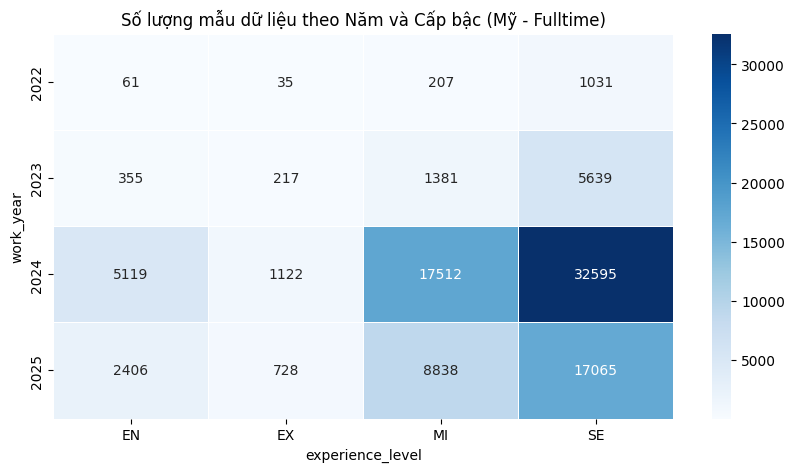

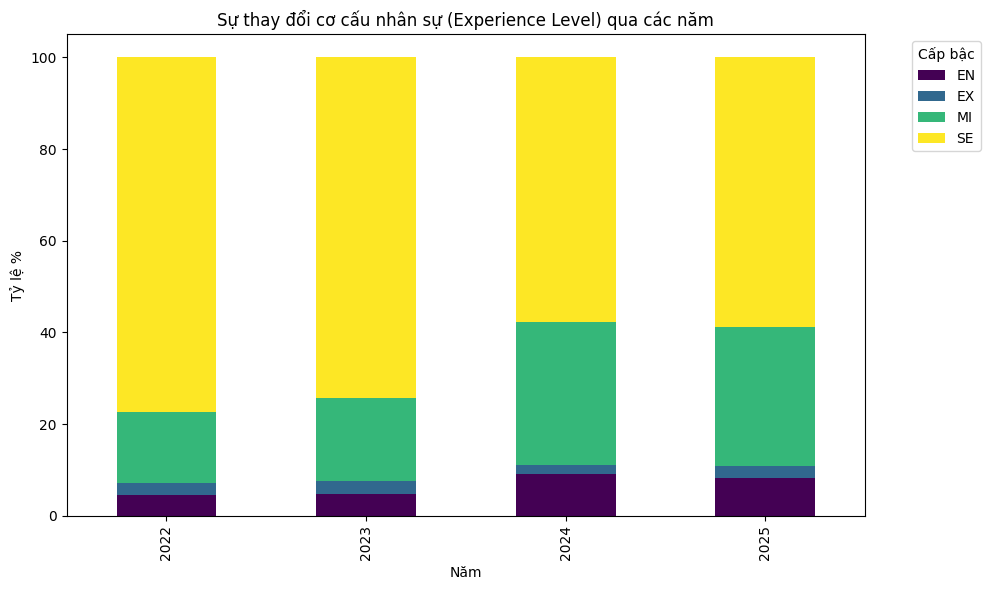

In [19]:
# 3. Vẽ biểu đồ nhiệt (Heatmap) để nhìn nhanh độ lớn của mẫu
plt.figure(figsize=(10, 5))
sns.heatmap(level_counts, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Số lượng mẫu dữ liệu theo Năm và Cấp bậc (Mỹ - Fulltime)')
plt.show()

# 4. Vẽ biểu đồ chồng (Stacked Bar Chart) để xem cơ cấu nhân sự
level_ratios.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Sự thay đổi cơ cấu nhân sự (Experience Level) qua các năm')
plt.ylabel('Tỷ lệ %')
plt.xlabel('Năm')
plt.legend(title='Cấp bậc', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Ghi chú: 
# EN: Entry-level / Junior
# MI: Mid-level
# SE: Senior
# EX: Executive / Director



**Đánh giá, kết hợp với kết luận từ **mục 2.3.2 trong notebook 02_general-eda**:**
- Entry-level/Junior (EN): Mẫu ít, chiếm chưa tới 10% tổng sample của năm. Có những outlier vượt trội, có thể là những sinh viên mới ra trường có thể nhận công ty nhỏ hoặc Big Tech, độ lệch chuẩn quá cao.
- Executive (EX): Mẫu quá ít, dưới 3%, EX là nhóm có biến động lương lớn nhất vì vậy nên dễ gây nhiễu.
- Senior (SE), Mid-level (MI): Là nhóm chiếm đa số đã có kỹ năng định hình rõ ràng. Mức lương của họ phản ánh chính xác nhất "giá thị trường sẵn sàng trả cho một người làm được việc". Và với số lượng sample mỗi năm >= 1000, vẫn hợp lệ để phân tích.

**Độ nhạy với lạm phát:**
Senior, Mid-level là người có quyền đàm phán (bargaining power). Nếu lạm phát tăng, họ là người đầu tiên đòi tăng lương hoặc nhảy việc. Do đó, lương Senior phản ánh nhịp đập kinh tế nhạy hơn Junior.  

Vậy ta sẽ **lọc lấy dữ liệu của Senior, Mid-level** để phân tích.

In [20]:
# Lọc chỉ lấy nhóm Senior (SE), Mid-level (MI) 
df_clean = df_clean[(df_clean['experience_level'] == 'SE') | (df_clean['experience_level'] == 'MI')].copy()
df_clean.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
6,2025,SE,FT,Engineer,199000,USD,199000,US,100,US,M
7,2025,SE,FT,Engineer,159200,USD,159200,US,100,US,M
8,2025,SE,FT,Systems Engineer,207000,USD,207000,US,100,US,M
9,2025,SE,FT,Systems Engineer,160000,USD,160000,US,100,US,M
10,2025,SE,FT,Analytics Engineer,191000,USD,191000,US,100,US,M


### B. Phân tích và đánh giá

**1. Tính lạm phát theo trend (xu hướng dài hạn)**  
**1.1. Tính lương thực tế (Feature Engineering)**   
Chúng ta sẽ chọn năm 2022 làm năm gốc (Base Year). Công thức tính Lương Thực Tế (Real Salary) quy về giá trị tiền của năm 2022:$$\text{Real Salary}_{2022} = \frac{\text{Salary In Year X}}{\text{CPI Year X}} \times \text{CPI}_{2022}$$

Chúng ta sẽ lấy dữ liệu chỉ số giá tiêu dùng (CPI - Consumer Price Index) của Mỹ vào để tính toán.
- Nguồn: [U.S. Bureau of Labor Statistics (BLS)](https://www.bls.gov/cpi/)
- Note:  
    - 2022, 2023: Số liệu trung bình năm chính thức.
    - 2024: Ước tính trung bình 10 tháng đầu năm.
    - 2025: Dự phóng với mức lạm phát giả định ~2.5%.

In [21]:
# Dữ liệu CPI Mỹ (Lấy 2022 làm gốc để so sánh giai đoạn hậu Covid)
cpi_data = {
    2022: 292.655, # Năm gốc
    2023: 304.700,
    2024: 314.000,
    2025: 322.000  # Dự phóng
}

# Hàm tính Real Salary (Lương thực tế)
def calculate_real_salary(row):
    """
    Tính lương thực (real salary) sau khi đã điều chỉnh theo lạm phát,
    quy đổi toàn bộ về sức mua của năm 2022.

    Tham số:
        row (Series): Một dòng dữ liệu chứa:
            - work_year: Năm làm việc
            - salary_in_usd: Lương danh nghĩa (nominal salary)

    Trả về:
        float: Lương thực đã được điều chỉnh theo CPI của năm 2022
    """
    year = row['work_year']
    nominal = row['salary_in_usd']
    
    if year in cpi_data:
        # Quy đổi về sức mua của năm 2022
        return nominal * (cpi_data[2022] / cpi_data[year])
    return nominal

# Áp dụng vào bảng dữ liệu
df_clean['real_salary_2022'] = df_clean.apply(calculate_real_salary, axis=1)

# Xem kết quả thử nghiệm trên 5 dòng
display(df_clean[['work_year', 'salary_in_usd', 'real_salary_2022']].head())

,work_year,salary_in_usd,real_salary_2022
6,2025,199000,180864.425466
7,2025,159200,144691.540373
8,2025,207000,188135.357143
9,2025,160000,145418.633540
10,2025,191000,173593.493789


**1.2. Tổng hợp và Phân tích (Aggregation)**  
Chúng ta sẽ **tính mức lương trung vị (median) qua từng năm** thay vì tính mean để loại bỏ ảnh hưởng của vài người lương quá cao làm lệch số liệu. Chúng ta sẽ có 2 đường dữ liệu median cho:
- Lương Danh Nghĩa (Nominal): Con số bạn nhìn thấy trên tin tuyển dụng.
- Lương Thực Tế (Real): Giá trị thật sự sau khi đã trừ đi lạm phát. Sự chênh lệch giữa 2 đường này chính là câu trả lời."

**Bước làm:**  
- Gom nhóm theo năm, sau đó tính median cho `salary_in_usd` và`real_salary_2022`, rồi `.sort_index()`, đảm bảo kết quả hiển thị theo trình tự thời gian tăng dầ

In [22]:
# Tính toán mức lương Trung Vị (Median) cho từng năm
salary_trends = df_clean.groupby('work_year')[['salary_in_usd', 'real_salary_2022']].median().sort_index()

# Đưa dữ liệu CPI vào bảng
cpi_series = pd.Series(cpi_data, name='CPI')
df_summary = salary_trends.join(cpi_series)
display(df_summary)

,salary_in_usd,real_salary_2022,CPI
work_year,,,
2022,142200.0,142200.000000,292.655
2023,151275.0,145294.995487,304.700
2024,160000.0,149123.566879,314.000
2025,158000.0,143600.900621,322.000


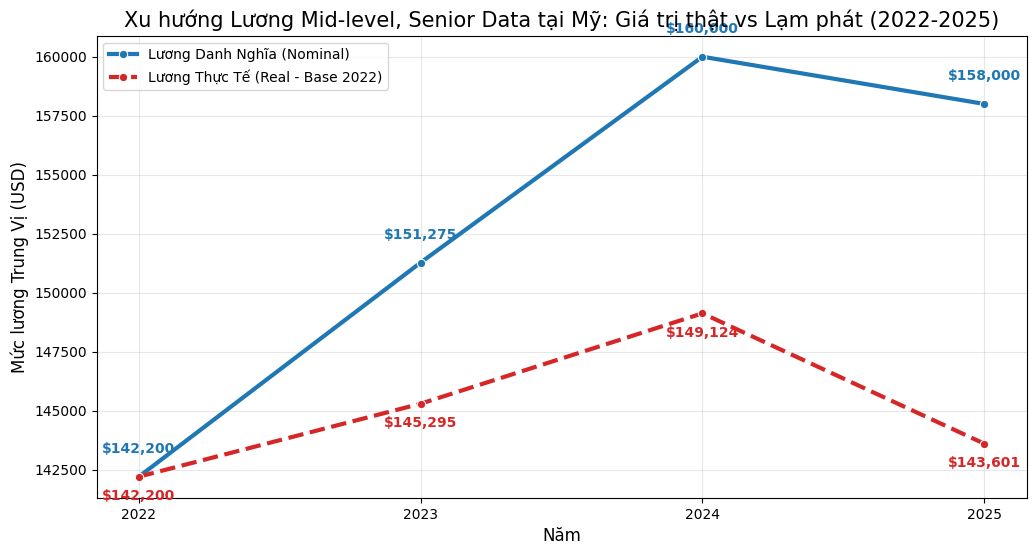

In [23]:
#2. VẼ BIỂU ĐỒ XU HƯỚNG (LINE CHART)
plt.figure(figsize=(12, 6))

# Vẽ Lương Danh Nghĩa (Màu Xanh - Đại diện cho con số trên hợp đồng)
sns.lineplot(data=df_summary, x=df_summary.index, y='salary_in_usd', 
             marker='o', label='Lương Danh Nghĩa (Nominal)', color='#1f77b4', linewidth=3)

# Vẽ Lương Thực Tế (Màu Đỏ - Đại diện cho sức mua quy đổi về 2022)
sns.lineplot(data=df_summary, x=df_summary.index, y='real_salary_2022', 
             marker='o', label='Lương Thực Tế (Real - Base 2022)', color='#d62728', linewidth=3, linestyle='--')

# Thêm nhãn giá trị (Annotations)
for year in df_summary.index:
    nominal = df_summary.loc[year, 'salary_in_usd']
    real = df_summary.loc[year, 'real_salary_2022']
    
    # Ghi số lương danh nghĩa (Xanh)
    plt.text(year, nominal + 1000, f"${nominal:,.0f}", 
             color='#1f77b4', ha='center', fontweight='bold')
    
    # Ghi số lương thực tế (Đỏ)
    plt.text(year, real - 1000, f"${real:,.0f}", 
             color='#d62728', ha='center', fontweight='bold')

plt.title('Xu hướng Lương Mid-level, Senior Data tại Mỹ: Giá trị thật vs Lạm phát (2022-2025)', fontsize=15)
plt.ylabel('Mức lương Trung Vị (USD)', fontsize=12)
plt.xlabel('Năm', fontsize=12)
plt.xticks(df_summary.index) # Chỉ hiện các năm có trong dữ liệu
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Nhận xét:**  
Dựa trên biểu đồ phân tích nhóm Mid-level, Senior từ 2022 đến 2025, ta thấy:
- Lương Danh Nghĩa (Đường xanh): Có xu hướng tăng đều qua các năm từ 2022-2024, năm 2024-2025 có giảm nhẹ từ 160 xuống 158.
- Lương Thực Tế (Đường đỏ): Nếu đường đỏ đi ngang hoặc tăng rất nhẹ so với đường xanh nghĩa là sức nua ko tăng nhiều, phần lớn mức tăng lương trong 3 năm qua chỉ dùng để bù đắp trượt giá. Theo hình, năm 2023, 2024: sức mua tăng cao hơn so với 2022, năm 2025: sức mua giảm mạnh, dù lương danh nghĩa vẫn cao.
Vậy ta có thể kết luận đơn giản dựa vào hình, **năm 2022-2024 lương tăng theo giá trị thực**, còn tốc độ tăng trưởng như thế nào, chúng ta cần phải tính tốc độ theo từng năm.

**2. Tính tốc độ Year over Year (YoY)**  
Để tính xem tốc độ tăng trưởng lương như thế nào so với tốc độ lạm phát, ta sẽ tính tốc độ tăng trưởng lương và tốc độ từng năm so với năm trước đó, và so sánh 2 giá trị với nhau.

**Bước làm:**  
- Ta sẽ tính **độ tăng trưởng lương** và **độ lạm phát**. Bằng cách dùng `pct_change()`: Hàm Percentage Change của Pandas, lấy (giá trị năm nay - giá trị năm trước) / giá trị năm trước cho `salary_in_usd` và `CPI`
- Tính **lãi thực** (Real Gain) bằng cách lấy **độ tăng trưởng lương** - **độ lạm phát**

In [24]:
# Tính tốc độ tăng trưởng YoY
df_summary['Salary_Growth_Pct'] = df_summary['salary_in_usd'].pct_change() * 100
df_summary['Inflation_Pct'] = df_summary['CPI'].pct_change() * 100

# Tính Gap (Lãi thực)
df_summary['Real_Gain_Pct'] = df_summary['Salary_Growth_Pct'] - df_summary['Inflation_Pct']

In [25]:
print("BẢNG TỔNG HỢP CÁC CHỈ SỐ TĂNG TRƯỞNG:")

# Chọn cột cần hiển thị
cols_to_show = ['salary_in_usd', 'real_salary_2022', 'Salary_Growth_Pct', 'Inflation_Pct', 'Real_Gain_Pct']

# Tạo bảng hiển thị riêng và ĐỔI TÊN CỘT (Rename) cho ngắn gọn
df_display = df_summary[cols_to_show].rename(columns={
    'salary_in_usd': 'Lương (USD)',
    'real_salary_2022': 'Lương Thực 22', # Tên ngắn để không xuống dòng
    'Salary_Growth_Pct': 'Tăng Lương %',
    'Inflation_Pct': 'Lạm Phát %',
    'Real_Gain_Pct': 'Lãi Thực %'
})

# Format số liệu
styled_table = df_display.style.format({
    'Lương (USD)': '{:,.0f}',
    'Lương Thực 22': '{:,.0f}',
    'Tăng Lương %': '{:+.2f}',
    'Lạm Phát %': '{:+.2f}',
    'Lãi Thực %': '{:+.2f}'
}).background_gradient(subset=['Lãi Thực %'], cmap='RdYlGn', vmin=-10, vmax=10) # background_gradient: Màu xanh nếu lãi dương, đỏ nếu lãi âm

display(styled_table)

BẢNG TỔNG HỢP CÁC CHỈ SỐ TĂNG TRƯỞNG:


,Lương (USD),Lương Thực 22,Tăng Lương %,Lạm Phát %,Lãi Thực %
work_year,,,,,
2022,"142,200","142,200",+nan,+nan,+nan
2023,"151,275","145,295",+6.38,+4.12,+2.27
2024,"160,000","149,124",+5.77,+3.05,+2.72
2025,"158,000","143,601",-1.25,+2.55,-3.80


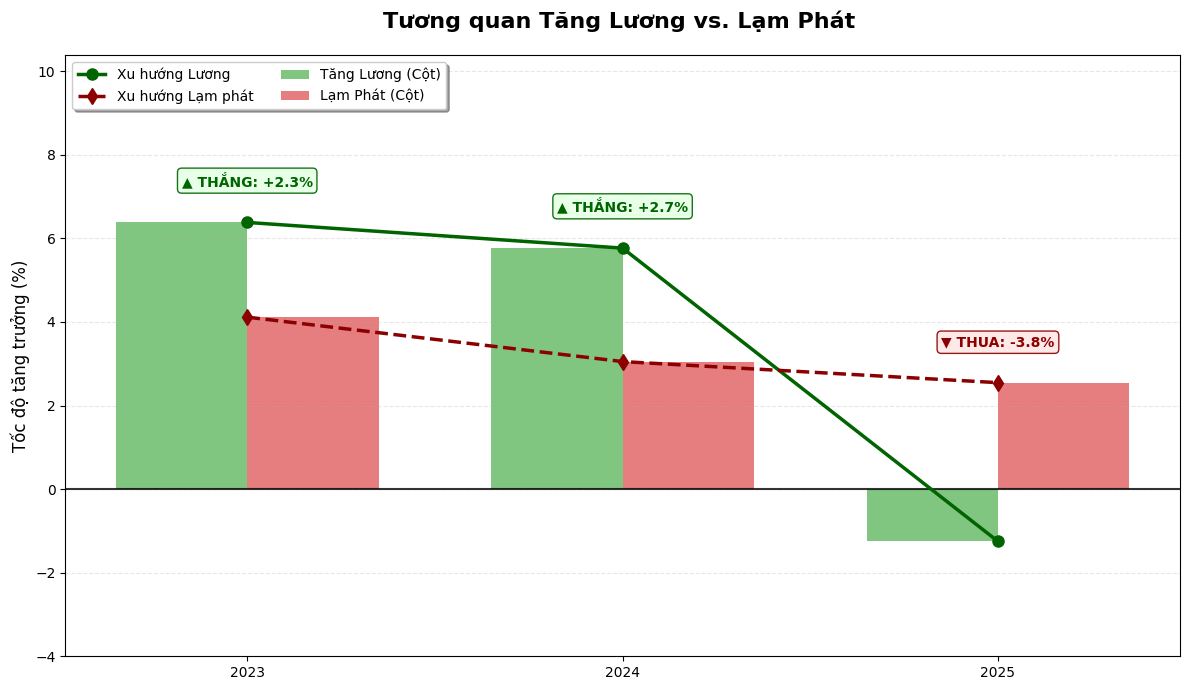

In [26]:
# 3. VẼ BIỂU ĐỒ KẾT HỢP 
# Bỏ năm 2022 vì không có dữ liệu so sánh
plot_data = df_summary.dropna().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 7))

width = 0.35
x = plot_data['work_year']

# BIỂU ĐỒ CỘT (BAR) 
# Giảm alpha (độ đậm) xuống 0.7 để làm nền cho đường line nổi bật hơn
ax1.bar(x - width/2, plot_data['Salary_Growth_Pct'], width, label='Tăng Lương (Cột)', color='#2ca02c', alpha=0.6)
ax1.bar(x + width/2, plot_data['Inflation_Pct'], width, label='Lạm Phát (Cột)', color='#d62728', alpha=0.6)

# BIỂU ĐỒ ĐƯỜNG (LINE) 
# zorder=10 để đảm bảo đường nằm đè lên trên cột
# Dùng màu đậm hơn màu cột tương ứng để tạo tương phản
ax1.plot(x, plot_data['Salary_Growth_Pct'], color='#006400', marker='o', markersize=8, linewidth=2.5, label='Xu hướng Lương', zorder=10)
ax1.plot(x, plot_data['Inflation_Pct'], color='#8B0000', marker='d', markersize=8, linewidth=2.5, linestyle='--', label='Xu hướng Lạm phát', zorder=10)

# --- CÁC THIẾT LẬP KHÁC ---
# Đường kẻ ngang mốc 0
ax1.axhline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.8)

# Trang trí trục
ax1.set_ylabel('Tốc độ tăng trưởng (%)', fontsize=12)
ax1.set_title('Tương quan Tăng Lương vs. Lạm Phát ', fontsize=16, pad=20, fontweight='bold')
ax1.set_xticks(x)
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')

# Xử lý Legend (Chú thích): Gom cả cột và đường vào 1 bảng
ax1.legend(loc='upper left', shadow=True, bbox_to_anchor=(0, 1), ncol=2) 
# ncol=2 để chia chú thích thành 2 cột cho gọn

# Tính toán giới hạn trục Y
all_values = pd.concat([plot_data['Salary_Growth_Pct'], plot_data['Inflation_Pct']])
min_y = all_values.min()
max_y = all_values.max()

# Ghi chú Thắng/Thua
for i, row in plot_data.iterrows():
    year = row['work_year']
    salary_growth = row['Salary_Growth_Pct']
    inflation = row['Inflation_Pct']
    gap = row['Real_Gain_Pct']
    
    # Lấy vị trí cao nhất để đặt text
    current_height = max(salary_growth, inflation, 0)
    
    # Logic xác định Thắng/Thua
    if gap >= 0:
        label = f"THẮNG: +{gap:.1f}%"
        color_text = '#006400' 
        icon = "▲"
        bg_color = '#e6ffe6' # Nền xanh nhạt
    else:
        label = f"THUA: {gap:.1f}%"
        color_text = '#8B0000' 
        icon = "▼"
        bg_color = '#ffe6e6' # Nền đỏ nhạt
        
    ax1.text(year, current_height + 0.8, f"{icon} {label}", 
             ha='center', va='bottom', color=color_text, fontweight='bold', fontsize=10,
             bbox=dict(facecolor=bg_color, edgecolor=color_text, boxstyle='round,pad=0.3', alpha=0.9))

# Set limit trục Y
bottom_limit = min(-4, min_y - 2) 
top_limit = max_y + 4 # Tăng khoảng trống bên trên để chứa label

plt.ylim(bottom_limit, top_limit)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Giai đoạn Hậu Covid 2022 - 2024: Giai đoạn ổn định, lương vẫn tăng ở mức >2% so với mức lạm phát. Mặc dù tốc độ lương năm 2024 giảm so với 2023, nhưng năm 2024 sẽ có cảm giác "dư dả" hơn do độ chênh lệch với lạm phát cao hơn.
- Giai đoạn 2024 - 2025: Khoảng cách (Gap) thu hẹp đáng kể, thậm chí có xu hướng chuyển sang âm hoặc đi ngang. Thị trường đã đảo chiều. Người lao động chịu tác động kép: "Lương giảm + Giá tăng". 

### C. Kết luận

Dựa trên nhận xét tốc độ tăng trưởng dài hạn và tăng trưởng qua từng năm, ta có kết luận như sau về lương của Mid-level và Senior ngành Data ở Mỹ trong năm 2022-2025:
- Năm 2022-2024: Lương tăng theo giá trị thực.
- Năm 2025: Lương thậm chí không tăng mà giảm so với năm ngoái, tốc độ lạm phạt vượt qua tốc độ tăng lương.  

**Lưu ý:**  
Phạm vi trả lời câ hỏi này còn chưa xét đến:
- Tỉ lệ Remote work giữa các năm (vd: năm 2023 có tỉ lệ remote work cao hơn năm 2024 thì có ảnh hưởng ko), tuy nhiên, theo **mục 2.3.5 Tương quan: Lương và Chế độ làm việc trong notebook 02-general_eda**, mức lương trung vị của nhóm Remote và On-site là ngang nhau vì vậy ta có thể tạm thời bỏ qua.
- Tỉ lệ Quy mô công ty (vd năm 2022-2023 lay off bùng nổ, nhiều nhân viên từ big tech chuyển sang công ty nhỏ hơn, mức lương có thay đổi ko). Tuy nhiên theo mục **2.2.6 company_size**, phân bố company size không đồng đều nên rất khó so sánh.

**Bài học:** 
- Chấp nhận thực tế mới: Đừng kỳ vọng mức tăng lương định kỳ cao như những năm trước. Hãy chuẩn bị tinh thần cho việc "đóng băng lương" (salary freeze) hoặc thưởng thấp hơn.
- Thích ứng với AI: Năm 2025 khả năng cao AI đã làm tốt các việc clean data hay visualize cơ bản. Bạn cần nâng cấp lên các kỹ năng mà AI chưa làm tốt: Tư duy chiến lược (Strategic thinking), Quản trị dữ liệu (Data Governance), và Hiểu biết nghiệp vụ sâu (Domain Knowledge).

## Câu hỏi 2

### A. Tiền xử lí

**1. Phân nhóm (Categorization)**  
Để phân nhóm, trước hết ta cần định nghĩa rõ ràng thế nào là "AI/ML" và thế nào là "Traditional Data Roles":
- AI/ML Engineers: Bao gồm các chức danh chứa từ khóa như "AI", "Machine Learning", "Computer Vision", "NLP", "Deep Learning".
- Traditional Data Roles: Bao gồm các chức danh truyền thống như "Data Analyst", "Data Scientist", "Data Engineer", "Business Intelligence", v.v., trừ khi chúng có tiền tố AI/ML.
- Other: còn lại

In [27]:
# 1. Lọc chỉ lấy dữ liệu từ năm 2022 trở đi
df = df[df['work_year'] >= 2022].copy()
    
# 2. Định nghĩa từ khóa 
# Nhóm AI
ai_keywords = [
        'AI', 'MACHINE LEARNING', 'ML', 'COMPUTER VISION', 'NLP', 
        'DEEP LEARNING', 'NEURAL', 'PROMPT', 'AUTONOMOUS', 'LLM', 'GENAI'
]
    
# Nhóm Data Truyền thống
data_keywords = [
        'DATA', 'ANALYST', 'ANALYTICS', 'SCIENTIST', 'BI', 'BUSINESS INTELLIGENCE',
        'STATISTICIAN', 'DATABASE', 'ETL', 'PIPELINE', 'ARCHITECT'
]

def categorize_strict(title):
    """
    Phân loại Job Title thành 3 nhóm chuyên môn dựa trên từ khóa.

    Logic hoạt động:
    - Chuyển đổi chuỗi đầu vào sang chữ in hoa để so sánh không phân biệt hoa thường.
    - Áp dụng cơ chế ưu tiên (Priority):
        1. Kiểm tra từ khóa AI/ML trước (để bắt các vị trí như 'AI Data Scientist').
        2. Nếu không có, kiểm tra tiếp từ khóa Data truyền thống.
        3. Nếu vẫn không khớp, gán nhãn là nhóm khác (Other).

    Args:
        title (str): Chuỗi chức danh công việc gốc (ví dụ: 'Principal Data Scientist', 'AI Engineer').

    Returns:
        str: Một trong 3 nhãn phân loại:
             - 'AI/ML Engineers'
             - 'Traditional Data Roles'
             - 'Other/Ambiguous'
    """
    title_upper = title.upper()
        
    # Ưu tiên check AI trước
    if any(kw in title_upper for kw in ai_keywords):
        return 'AI/ML Engineers'
        
    # Check Data sau
    elif any(kw in title_upper for kw in data_keywords):
        return 'Traditional Data Roles'
        
    # Còn lại đẩy ra Other
    else:
        return 'Other/Ambiguous'

df['role_category'] = df['job_title'].apply(categorize_strict)
    
# 3. Thống kê kết quả
print("--- Phân bố số lượng các nhóm ---")
print(df['role_category'].value_counts())
print("\n")
    
# 4. Check kỹ nhóm 'Other' xem có job nào bị xét sai/thiếu ko
other_jobs = df[df['role_category'] == 'Other/Ambiguous']['job_title'].unique()
print(f"--- Các Job Title bị đẩy vào nhóm 'Other' (Tổng: {len(other_jobs)}) ---")
print(other_jobs)



--- Phân bố số lượng các nhóm ---
role_category
Traditional Data Roles    59629
Other/Ambiguous           34698
AI/ML Engineers           10814
Name: count, dtype: int64


--- Các Job Title bị đẩy vào nhóm 'Other' (Tổng: 89) ---
['Engineer' 'Systems Engineer' 'Product Manager' 'Research Engineer'
 'Software Developer' 'Software Engineer' 'Manager' 'Stage'
 'Research Assistant' 'Associate' 'Quantitative Researcher'
 'Software Development Engineer' 'Cloud Engineer' 'Technical Recruiter'
 'Director of Product Management' 'Developer' 'Full Stack Engineer'
 'Consultant' 'Application Developer' 'Statistical Programmer'
 'Solutions Engineer' 'Backend Engineer' 'Engineering Manager'
 'Full Stack Developer' 'Executive' 'Alternance' 'Technical Lead'
 'Account Executive' 'Python Developer' 'Sales Engineer'
 'Robotics Engineer' 'Technical Support Specialist'
 'Technical Support Engineer' 'Platform Engineer' 'Copywriter'
 'Quantitative Trader' 'Research Associate' 'DevOps Engineer'
 'QA Engineer' '

**Trường hợp tranh cãi:**  
Research Scientist / Applied Scientist: Ở các công ty Big Tech (Amazon, Meta) thường là vị trí làm về AI/ML (lương cực cao), nhưng ở đây bị đẩy họ "Traditional Data Roles" thì có thể mất dữ liệu quan trọng của nhóm AI.

**2. Kiểm tra tính hợp lệ (Fairness Check)**  
Trước khi so sánh lương, ta phải kiểm tra xem cỡ mẫu  có đủ lớn và phân phối kinh nghiệm (Experience Level) có tương đồng không. Nếu nhóm AI toàn là Senior (SE) còn nhóm Traditional toàn là Junior (EN), việc nhóm AI lương cao hơn là hiển nhiên do kinh nghiệm, không phải do "cơn sốt AI". Đây là yếu tố công bằng (Fairness) cần xét đến.

**Bước làm:**  
- Đếm số lượng bản ghi theo từng nhóm và từng năm.
- Kiểm tra tỷ lệ % các mức kinh nghiệm (EN, MI, SE, EX) trong từng nhóm.

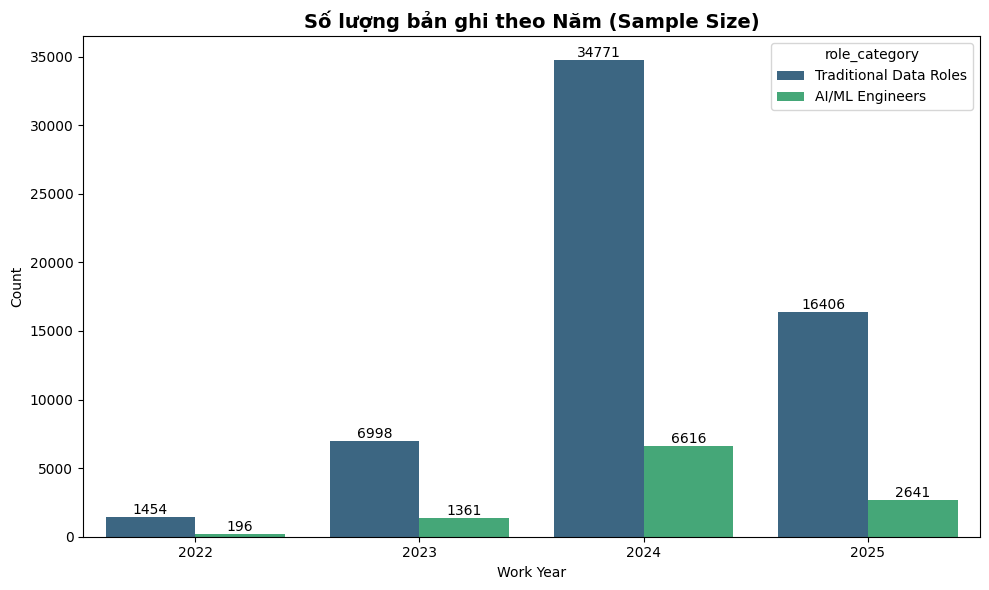

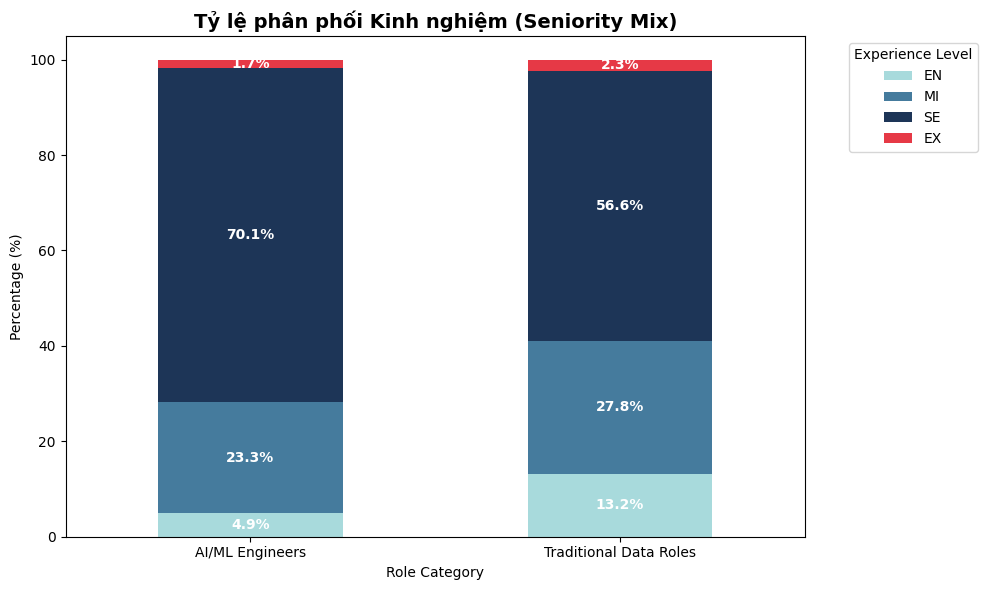


--- Bảng dữ liệu: Tỷ lệ kinh nghiệm (%) ---
experience_level           EN     MI     SE    EX
role_category                                    
AI/ML Engineers          4.88  23.35  70.08  1.69
Traditional Data Roles  13.24  27.82  56.60  2.34


In [28]:
# Chỉ lấy 2 nhóm chính để phân tích
df_main = df[df['role_category'] != 'Other/Ambiguous'].copy()

# Sắp xếp thứ tự kinh nghiệm: EN -> MI -> SE -> EX
exp_order = ['EN', 'MI', 'SE', 'EX']
df_main['experience_level'] = pd.Categorical(df_main['experience_level'], categories=exp_order, ordered=True)

# 1: Số lượng mẫu theo năm (Countplot)
plt.figure(figsize=(10, 6)) # Tạo khung hình riêng

ax1 = sns.countplot(
    data=df_main, 
    x='work_year', 
    hue='role_category', 
    palette='viridis'
)

plt.title('Số lượng bản ghi theo Năm (Sample Size)', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Work Year')

# Hiển thị số lượng trên cột
for container in ax1.containers:
    ax1.bar_label(container)

plt.tight_layout()
plt.show()

#  2: Tỷ lệ phân phối Kinh nghiệm (Stacked Bar)
# Tạo bảng chéo chuẩn hóa
exp_dist = pd.crosstab(df_main['role_category'], df_main['experience_level'], normalize='index') * 100

# Vẽ biểu đồ 
# kind='bar' (thẳng đứng) thay vì 'barh' (ngang)
ax2 = exp_dist.plot(
    kind='bar', 
    stacked=True, 
    color=['#a8dadc', '#457b9d', '#1d3557', '#e63946'], 
    figsize=(10, 6)
)

plt.title('Tỷ lệ phân phối Kinh nghiệm (Seniority Mix)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)') # Đổi nhãn trục từ X sang Y
plt.xlabel('Role Category')
plt.xticks(rotation=0)

# Hiển thị số % lên biểu đồ (Vị trí center)
for c in ax2.containers:
    # label_type='center' để số nằm giữa đoạn màu
    ax2.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontsize=10, weight='bold')

# Di chuyển chú thích (legend) ra ngoài để không che biểu đồ nếu cần
plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# In bảng số liệu chi tiết để đối chiếu ---
print("\n--- Bảng dữ liệu: Tỷ lệ kinh nghiệm (%) ---")
print(exp_dist.round(2))

**Nhận xét:**  
- Số lượng mẫu qua các năm (2022-2025) đều rất ổn để phân tích.
- Sự chênh lệch về thâm niên (Seniority Skew):
    - Nhóm AI/ML có tới 70.08% là Senior (SE).
    - Nhóm Traditional chỉ có 56.60% là Senior.
Nhóm Traditional phải "gánh" tới 13.24% nhân sự mới ra trường (EN - Entry Level), trong khi AI chỉ có 4.88%. Nếu so sánh gộp chung, lương trung bình của nhóm AI sẽ cao hơn một phần là do họ "già dặn" hơn, chứ không hẳn do công nghệ AI được trả giá cao hơn.

### B. Phân tích và đánh giá

**1. Vẽ biểu đồ xu hướng**  
Vẽ 2 biểu đồ đường cạnh nhau.
- Bên trái: Lương trung bình toàn bộ (bị nhiễu bởi thâm niên).
- Bên phải: Lương trung bình chỉ của nhóm Senior (SE) 

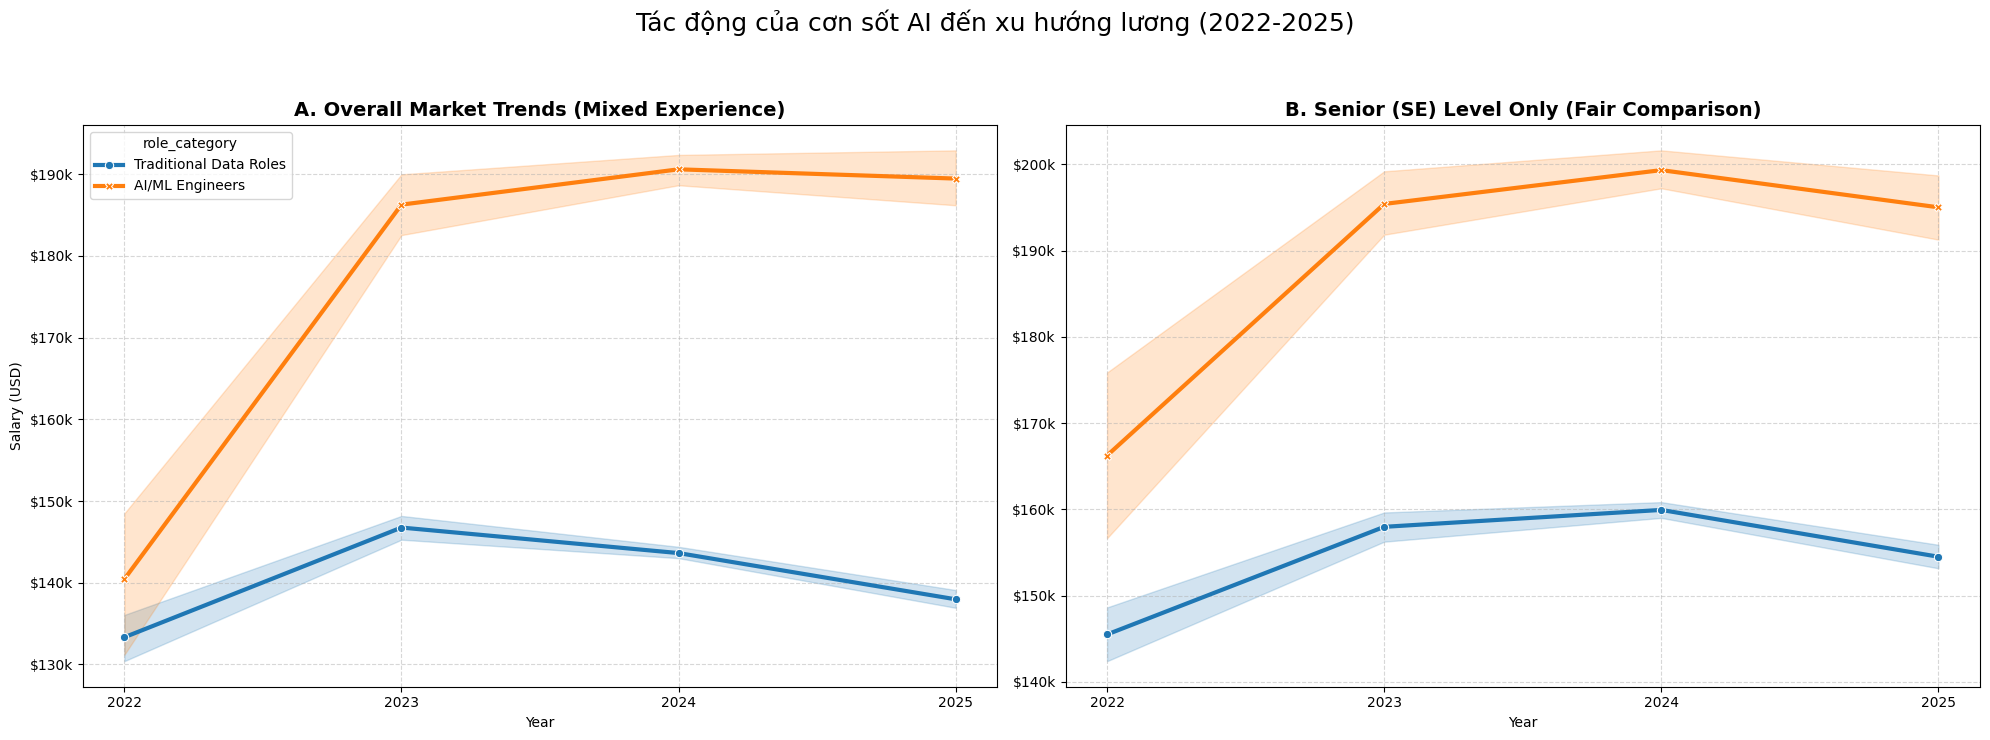

In [29]:
# Tạo subplot 1 hàng 2 cột
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- BIỂU ĐỒ 1: OVERALL ---
sns.lineplot(
    data=df_main, 
    x='work_year', 
    y='salary_in_usd', 
    hue='role_category', 
    style='role_category',
    markers=True, 
    dashes=False,
    linewidth=3,
    errorbar=('ci', 95), # Vùng tin cậy 95%
    ax=axes[0]
)
axes[0].set_title('A. Overall Market Trends (Mixed Experience)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Salary (USD)')
axes[0].set_xlabel('Year')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 2: SENIOR ONLY  ---
# Lọc chỉ lấy Senior (SE)
df_senior = df_main[df_main['experience_level'] == 'SE'].copy()

sns.lineplot(
    data=df_senior, 
    x='work_year', 
    y='salary_in_usd', 
    hue='role_category', 
    style='role_category',
    markers=True, 
    dashes=False,
    linewidth=3,
    errorbar=('ci', 95),
    ax=axes[1],
    legend=False 
)
axes[1].set_title('B. Senior (SE) Level Only (Fair Comparison)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('') 
axes[1].set_xlabel('Year')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Định dạng trục Y thành tiền tệ ($150k)
formatter = ticker.FuncFormatter(lambda x, pos: '${:,.0f}'.format(x/1000) + 'k')
axes[0].yaxis.set_major_formatter(formatter)
axes[1].yaxis.set_major_formatter(formatter)

# Chỉnh trục X
axes[0].set_xticks([2022, 2023, 2024, 2025])
axes[1].set_xticks([2022, 2023, 2024, 2025])

plt.suptitle('Tác động của cơn sốt AI đến xu hướng lương (2022-2025)', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

**Nhận xét**  
**Độ chênh lệch:**  
Ở Biểu đồ A (Overall), khoảng cách (Gap) giữa đường AI/ML và Traditional Data rất lớn, cảm giác như làm AI lương cao Data rất nhiều, gấp ~1,5 lần. Khoảng cách này bị phóng đại. Sự thật: Như ta đã tìm ra ở Bước 2, nhóm AI có tới 70% là Senior, trong khi nhóm Data có nhiều Junior/Entry level hơn.  

Có thể kết luận, biểu đồ A là cái mà giả định "Lương AI cao ngất ngưởng". Nhưng Biểu đồ B (Senior Only) mới là thực tế thị trường dành cho người có kinh nghiệm. Tại biểu đồ B, khoảng cách thu hẹp lại đáng kể -> AI Premium (phần trả thêm cho AI) có thật, nhưng không "khủng" như lời đồn. Vậy bước sau, ta sẽ **tập trung vào phân tích nhóm Senior.**

**Độ ổn định (Volatility):**  
Quan sát vùng bóng mờ, đường Traditional Data thường có vùng bóng mờ rất hẹp -> Mức lương đã được chuẩn hóa (Standardized), ít biến động, rủi ro thấp. 

Đường AI/ML thường có vùng bóng mờ rộng hơn -> Mức lương dao động mạnh, nhất là ở năm 2022 khi ChatGPT mới bùng nổ, các năm về sau lương giao động bắt đầu thu hẹp lại.

**4 Kiểm định độ dốc tổng thể (Slope Calculation)**  
Để trả lời câu hỏi "Nhóm nào tăng trưởng nhanh hơn?", ta sử dụng Hồi quy tuyến tính (Linear Regression) phương trình: $y = ax + b$$x$:   
- Năm (work_year)$y$:
- Lương (salary_in_usd)$a$ (Slope - Độ dốc): Đây là con số quan trọng nhất. Nó cho biết: "Trung bình mỗi năm, lương của vị trí này tăng (hoặc giảm) bao nhiêu USD?"
    - Nếu Slope AI > Slope Traditional: AI đang thắng thế về tốc độ.
    - Nếu Slope AI âm (< 0): Lương AI đang bị điều chỉnh giảm sau cơn sốt.

**Bước làm:**  
- Slope ($a$): Sử dụng `numpy.polyfit` bậc 1 để tìm xu hướng tổng thể. 

In [30]:
# 1. Tính trung bình lương theo Năm & Role
agg_data = df_senior.groupby(['role_category', 'work_year'])['salary_in_usd'].mean().reset_index()

# --- XỬ LÝ & IN BẢNG DỮ LIỆU THÔ (CÓ DẤU PHẨY) ---
print("--- Dữ liệu trung bình thực tế (Senior) ---")

# Tạo pivot table
pivot_df = agg_data.pivot(index='work_year', columns='role_category', values='salary_in_usd')

# Format hiển thị
print(pivot_df.map(lambda x: f"{x:,.0f}" if pd.notnull(x) else "-"))
print("\n")


# 2. Tính toán Độ dốc (Slope)
results = []

for role in agg_data['role_category'].unique():
    role_data = agg_data[agg_data['role_category'] == role]
    
    # Chỉ tính khi có nhiều hơn 1 điểm dữ liệu (để vẽ được đường thẳng)
    if len(role_data) > 1:
        # Hồi quy tuyến tính bậc 1: y = ax + b
        slope, intercept = np.polyfit(role_data['work_year'], role_data['salary_in_usd'], 1)
        
        # Tính lương theo xu hướng năm 2025 (Trendline)
        val_2025 = slope * 2025 + intercept
        
        results.append({
            'Category': role,
            'Slope ($/Year)': slope,  # Giữ số thô để sort
            'Avg Salary 2025 (Trend)': val_2025
        })

# 3. Tạo DataFrame kết quả
df_results = pd.DataFrame(results)

# Sắp xếp giảm dần theo độ dốc
df_results = df_results.sort_values(by='Slope ($/Year)', ascending=False)


# Thêm dấu + cho số dương, dấu phẩy ngăn cách hàng nghìn
df_display = df_results.copy()
df_display['Slope ($/Year)'] = df_display['Slope ($/Year)'].apply(lambda x: f"{x:+,.0f}")
df_display['Avg Salary 2025 (Trend)'] = df_display['Avg Salary 2025 (Trend)'].apply(lambda x: f"{x:,.0f}")

# Set Index là cột Category
df_display = df_display.set_index('Category')

print("--- KẾT QUẢ ĐỘ DỐC & DỰ BÁO (SENIOR ONLY) ---")
print(df_display)

--- Dữ liệu trung bình thực tế (Senior) ---
role_category AI/ML Engineers Traditional Data Roles
work_year                                           
2022                  166,232                145,488
2023                  195,404                157,967
2024                  199,326                159,928
2025                  195,014                154,500


--- KẾT QUẢ ĐỘ DỐC & DỰ BÁO (SENIOR ONLY) ---
                       Slope ($/Year) Avg Salary 2025 (Trend)
Category                                                     
AI/ML Engineers                +9,027                 202,534
Traditional Data Roles         +2,900                 158,821


**Nhận xét:**   
**Sự chênh lệch slope:**  
- AI/ML Engineers: Slope = +9,027 USD/năm.
- Traditional Data Roles: Slope = +2,900 USD/năm.
- Tốc độ tăng trưởng lương trung bình của nhóm AI nhanh gấp 3.1 lần so với nhóm Data truyền thống trong giai đoạn này. Điều này **xác nhận giả thuyết: Cơn sốt ChatGPT đã tạo ra một lực đẩy mạnh mẽ, khiến giá trị thị trường của kỹ sư AI tăng vọt so với mặt bằng chung.**

**Khoảng cách thu nhập:**  
- Năm 2022: Chênh lệch là ~21,000 USD (166k - 145k).
- Năm 2025: Chênh lệch là ~40,000 USD (195k - 154k).
- Kết luận: Khoảng cách giàu nghèo giữa "người làm AI" và "người làm Data thuần" đã tăng gấp đôi sau 3 năm.

### C. Kết luận

- Tác động cấu trúc: Cơn sốt AI đã tái cấu trúc mặt bằng lương, nới rộng khoảng cách thu nhập (Salary Gap) giữa nhóm AI và nhóm Data truyền thống từ mức ~21k USD (2022) lên ~40k USD (2025).

- Với AI/ML Engineers: Họ là những người hưởng lợi lớn nhất. Mức tăng trưởng trung bình 9,000 USD/năm (gấp 3 lần nhóm còn lại) cho thấy thị trường sẵn sàng trả một mức "AI Premium" rất cao. Tuy nhiên, đà tăng này chủ yếu diễn ra vào 2023 và đang có dấu hiệu đi ngang trong 2025.

**Hạn chế:**  
Hạn chế của hàm hồi quy tuyến tính `polyfit` khi áp dụng cho toàn bộ giai đoạn 4 năm 2022- 2025) sẽ vẽ một đường thẳng trung bình đi qua tất cả các điểm. Vì năm 2023 tăng quá mạnh (cú nhảy vọt), nó kéo cả độ dốc trung bình lên cao (+9k), làm lu mờ thực tế là từ 2024 sang 2025 đường biểu đồ đang đi ngang, thậm chí đi xuống. 

Ở hình B phía bên trên, năm 2023 AI phát triển mạnh, nhưng sang năm 2023-2025, độ dốc giảm, đường tăng trưởng ngang hoẵ thậm chí có xu hướng giảm, nhưng slope tổng thể vẫn là +9k

**Bài học:**
- Đối với các Data Analysts/Scientists truyền thống:
    - Đừng hoảng loạn, mức tăng trưởng +2,900/năm vẫn là con số tích cực và bền vững (cao hơn lạm phát ở nhiều nơi).
    - Chiến lược thu nhập: Để xóa bỏ khoảng cách $40,000 kia, con đường ngắn nhất là tích hợp AI vào quy trình làm việc (AI-augmented Analyst) chứ không nhất thiết phải chuyển hẳn sang làm kỹ sư xây dựng mô hình (Model Builder).
-  Dành cho AI/ML Engineers: Đừng chủ quan, giai đoạn "AI bùng nổ" (2023) với mức tăng 30k/năm đã kết thúc. Năm 2025 lương đang chững lại.